# DATA266 Lab 1 - Task 2
## Yelp polarity sentiment classification (zohebw)

Three models, all with embeddings **learned from scratch** - no pretrained embeddings and no
pretrained language models anywhere in the pipeline.

| | M1 (baseline) | M2 | M3 |
|---|---|---|---|
| Architecture | BiLSTM + mean pooling | multi-kernel TextCNN | BiLSTM + additive attention |
| Changes vs baseline | - | encoder family | depth, width, pooling, schedule |

Training is run from the command line (`src/train.py --config configs/<model>.yaml`); this
notebook loads the completed runs.

In [1]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    # Walk up to the repo root (the directory holding common/ and requirements.txt)
    # so the notebook runs from anywhere - no hard-coded personal paths (workplan 5).
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'task2_sentiment/zoheb_waghu/src'))
import numpy as np, pandas as pd, torch
from common.config import load_config
MEMBER = ROOT/'task2_sentiment/zoheb_waghu'
OUT, CACHE = MEMBER/'outputs', MEMBER/'data_processed'
cfg = load_config(MEMBER/'configs/m1_baseline_bilstm.yaml')
print('torch', torch.__version__, '| mps', torch.backends.mps.is_available())

torch 2.5.1 | mps True


## 1. Data preprocessing (10 marks)

### 1.1 Dataset note
The brief's task text says **Yelp polarity**; the folder tree in the same brief labels the data
IMDB. Proceeding on Yelp polarity - `data.dataset` in the config switches it in one line.

In [2]:
eda = json.loads((CACHE/'eda.json').read_text())
pd.Series(eda)[['train_rows','val_rows','test_rows','vocab_size','train_pos_frac','test_pos_frac',
                'token_len_mean','token_len_median','token_len_p95','token_len_max',
                'truncated_frac','stopwords_removed','oov_rate_test']].to_frame('value')

,value
train_rows,89997
val_rows,9999
test_rows,38000
vocab_size,30000
train_pos_frac,0.501861
test_pos_frac,0.5
token_len_mean,70.126882
token_len_median,51.0
token_len_p95,194.0
token_len_max,558


### 1.2 Length distribution, class balance and dataset summary

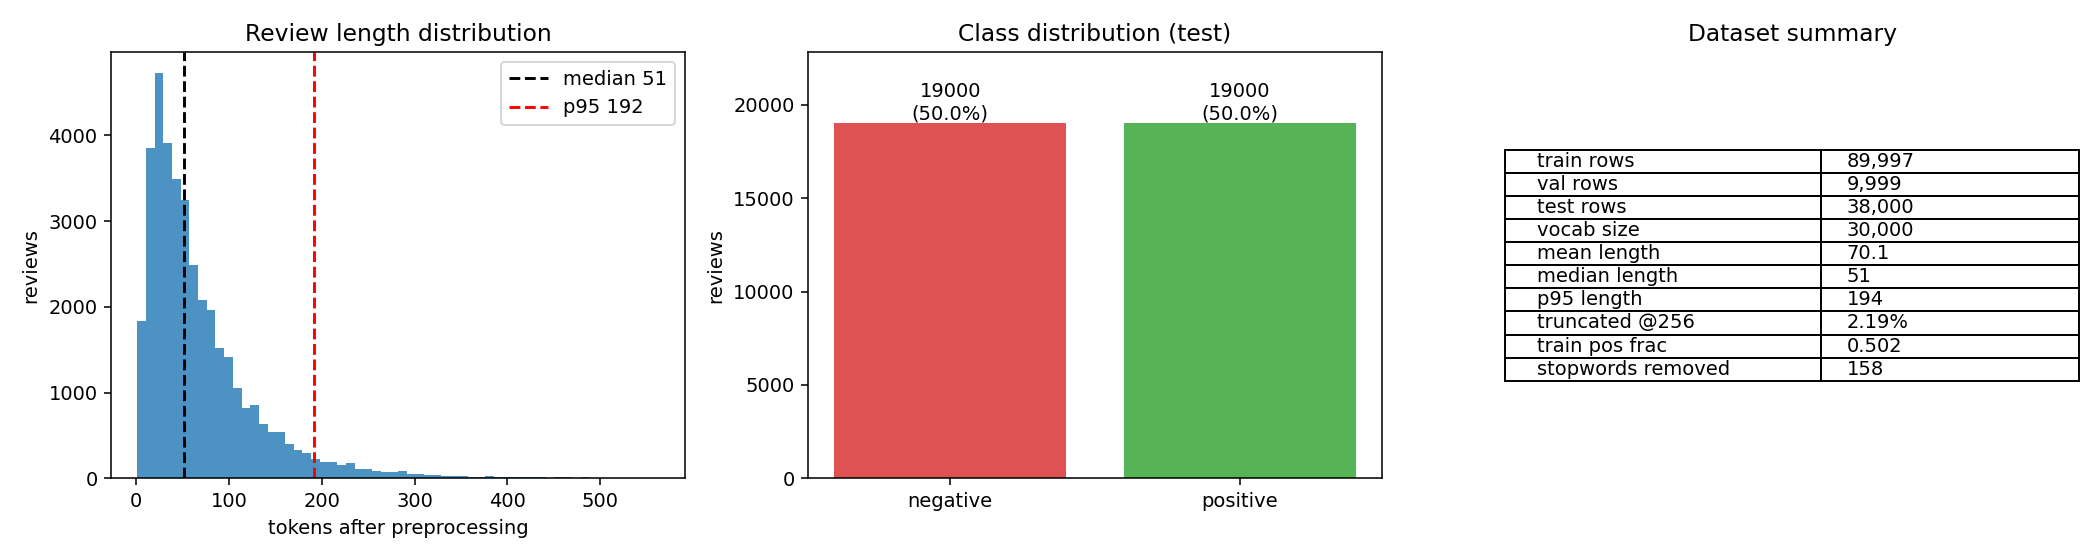

In [3]:
from IPython.display import Image, display
display(Image(filename=str(OUT/'plots/eda_overview.png')))

### 1.3 Negation handling - the decision and its justification

NLTK's English stopword list contains **39 words that invert sentiment**: `not`, `no`, `nor`,
and every `n't` contraction form. Removing them turns *"the food was not good"* into
*"food good"*. My pipeline therefore:

1. expands contractions **before** stopword removal, so `don't` -> `do not` rather than `do`
2. removes stopwords with the negation words **excluded from removal**

In [4]:
from nltk.corpus import stopwords
from data import get_stopwords, clean_text, NEGATIONS
full = set(stopwords.words('english'))
kept = get_stopwords('nltk_english_minus_negations')
print('full NLTK stopword list:      %d' % len(full))
print('list actually used:           %d' % len(kept))
print('sentiment-inverting words kept: %d' % (len(full) - len(kept)))
print('\nexamples kept:', sorted(full - kept)[:14])

full NLTK stopword list:      198
list actually used:           158
sentiment-inverting words kept: 40

examples kept: ['ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'don', "don't", 'hadn', "hadn't", 'hasn']


In [5]:
pp = cfg['preprocess']
demo = "The food was not good and I won't be coming back. Service wasn't great either!"
print('raw          :', demo)
print('my pipeline  :', clean_text(demo, pp, kept, None))
print('naive (full stopword removal):', clean_text(demo, pp, full, None))

raw          : The food was not good and I won't be coming back. Service wasn't great either!
my pipeline  : ['food', 'not', 'good', 'not', 'coming', 'back', 'service', 'not', 'great', 'either']
naive (full stopword removal): ['food', 'good', 'coming', 'back', 'service', 'great', 'either']


The naive pipeline deletes every negation, leaving tokens that read as positive. The
`contains_negation` robustness slice in the metrics table measures whether this decision
actually paid off.

## 2. Models (15 marks)

Defined in [src/models.py](src/models.py). Embeddings are `nn.Embedding` initialised uniformly
in [-0.1, 0.1] and trained end to end.

In [6]:
from models import build_model
rows = []
for name in ['m1_baseline_bilstm','m2_cnn_multikernel','m3_bilstm_attention']:
    c = load_config(MEMBER/f'configs/{name}.yaml')
    m = build_model(c, eda['vocab_size'])
    rows.append({'config': name, 'model': c['model']['name'], 'emb_dim': c['embedding']['dim'],
                 'pooling': c['model']['pooling'], 'dropout': c['model']['dropout'],
                 'optimizer': c['train']['optimizer'], 'lr': c['train']['lr'],
                 'batch': c['train']['batch_size'], 'epochs': c['train']['epochs'],
                 'params': m.num_params()})
pd.DataFrame(rows)

,config,model,emb_dim,pooling,dropout,optimizer,lr,batch,epochs,params
0,m1_baseline_bilstm,bilstm_mean,128,mean,0.3,adam,0.001,64,8,4104449
1,m2_cnn_multikernel,cnn_multikernel,128,max,0.5,adam,0.001,64,8,4135681
2,m3_bilstm_attention,bilstm_attention,256,additive_attention,0.4,adamw,0.002,32,12,10441217


In [7]:
import inspect
from models import BiLSTMAttention
print(inspect.getsource(BiLSTMAttention.forward))

    def forward(self, x, lengths=None, return_attn=False):
        pad_mask = (x == 0)
        h, _ = self.lstm(self.emb(x))
        scores = self.att_vec(torch.tanh(self.att_proj(h))).squeeze(-1)   # (B, T)
        scores = scores.masked_fill(pad_mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (h * w).sum(1)
        logit = self.head(self.drop(pooled)).squeeze(-1)
        return (logit, w.squeeze(-1)) if return_attn else logit



## 3. Results - all required metrics (per model)

In [8]:
team = pd.read_csv(MEMBER/'metrics_report.csv')           # team-agreed schema (31 cols)
mr   = pd.read_csv(MEMBER/'metrics_report_extended.csv')  # my full set (46 cols)
print('team schema columns: %d | extended: %d' % (len(team.columns), len(mr.columns)))
print('in extended but not in the team header (renames + genuine extras):')
print(' ', sorted(set(mr.columns) - set(team.columns)))
mr[['model_name','accuracy','f1_macro','f1_micro','f1_weighted','roc_auc','pr_auc','mcc',
    'brier_score','ece','param_count','train_seconds','examples_per_sec','peak_memory_gb']].round(5)

team schema columns: 31 | extended: 46
in extended but not in the team header (renames + genuine extras):
  ['acc_ci_high', 'acc_ci_low', 'checkpoint_id', 'config_path', 'device', 'ece', 'f1_macro_ci_high', 'f1_macro_ci_low', 'fn', 'fp', 'mcc_ci_high', 'mcc_ci_low', 'param_count', 'slice_highpunct_error_rate', 'slice_highpunct_f1_macro', 'slice_long_error_rate', 'slice_long_f1_macro', 'slice_negation_error_rate', 'slice_negation_f1_macro', 'slice_short_error_rate', 'slice_short_f1_macro', 'split', 'tn', 'tp', 'train_seconds']


,model_name,accuracy,f1_macro,f1_micro,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece,param_count,train_seconds,examples_per_sec,peak_memory_gb
0,bilstm_mean,0.93313,0.93312,0.93313,0.93312,0.98282,0.98336,0.86664,0.05038,0.01660,4104449,213.78,1683.94,2.0999
1,cnn_multikernel,0.93553,0.93553,0.93553,0.93553,0.98359,0.98410,0.87105,0.04799,0.00566,4135681,124.81,2884.38,1.1425
2,bilstm_attention,0.93892,0.93892,0.93892,0.93892,0.98523,0.98542,0.87801,0.04560,0.00514,10441217,2427.59,148.29,5.6823


In [9]:
mr[['model_name','tn','fp','fn','tp','acc_ci_low','acc_ci_high','f1_macro_ci_low',
    'f1_macro_ci_high','mcc_ci_low','mcc_ci_high','mcnemar_stat_vs_baseline',
    'mcnemar_p_vs_baseline']]

,model_name,tn,fp,fn,tp,acc_ci_low,acc_ci_high,f1_macro_ci_low,f1_macro_ci_high,mcc_ci_low,mcc_ci_high,mcnemar_stat_vs_baseline,mcnemar_p_vs_baseline
0,bilstm_mean,18009,991,1550,17450,0.93071,0.93566,0.93069,0.93564,0.86180,0.87167,BASELINE,BASELINE
1,cnn_multikernel,17797,1203,1247,17753,0.93297,0.93808,0.93297,0.93808,0.86595,0.87619,3.7448,5.297e-02
2,bilstm_attention,17654,1346,975,18025,0.93653,0.94126,0.93651,0.94125,0.87323,0.88268,24.4699,7.548e-07


### 3.1 Confusion matrices and calibration

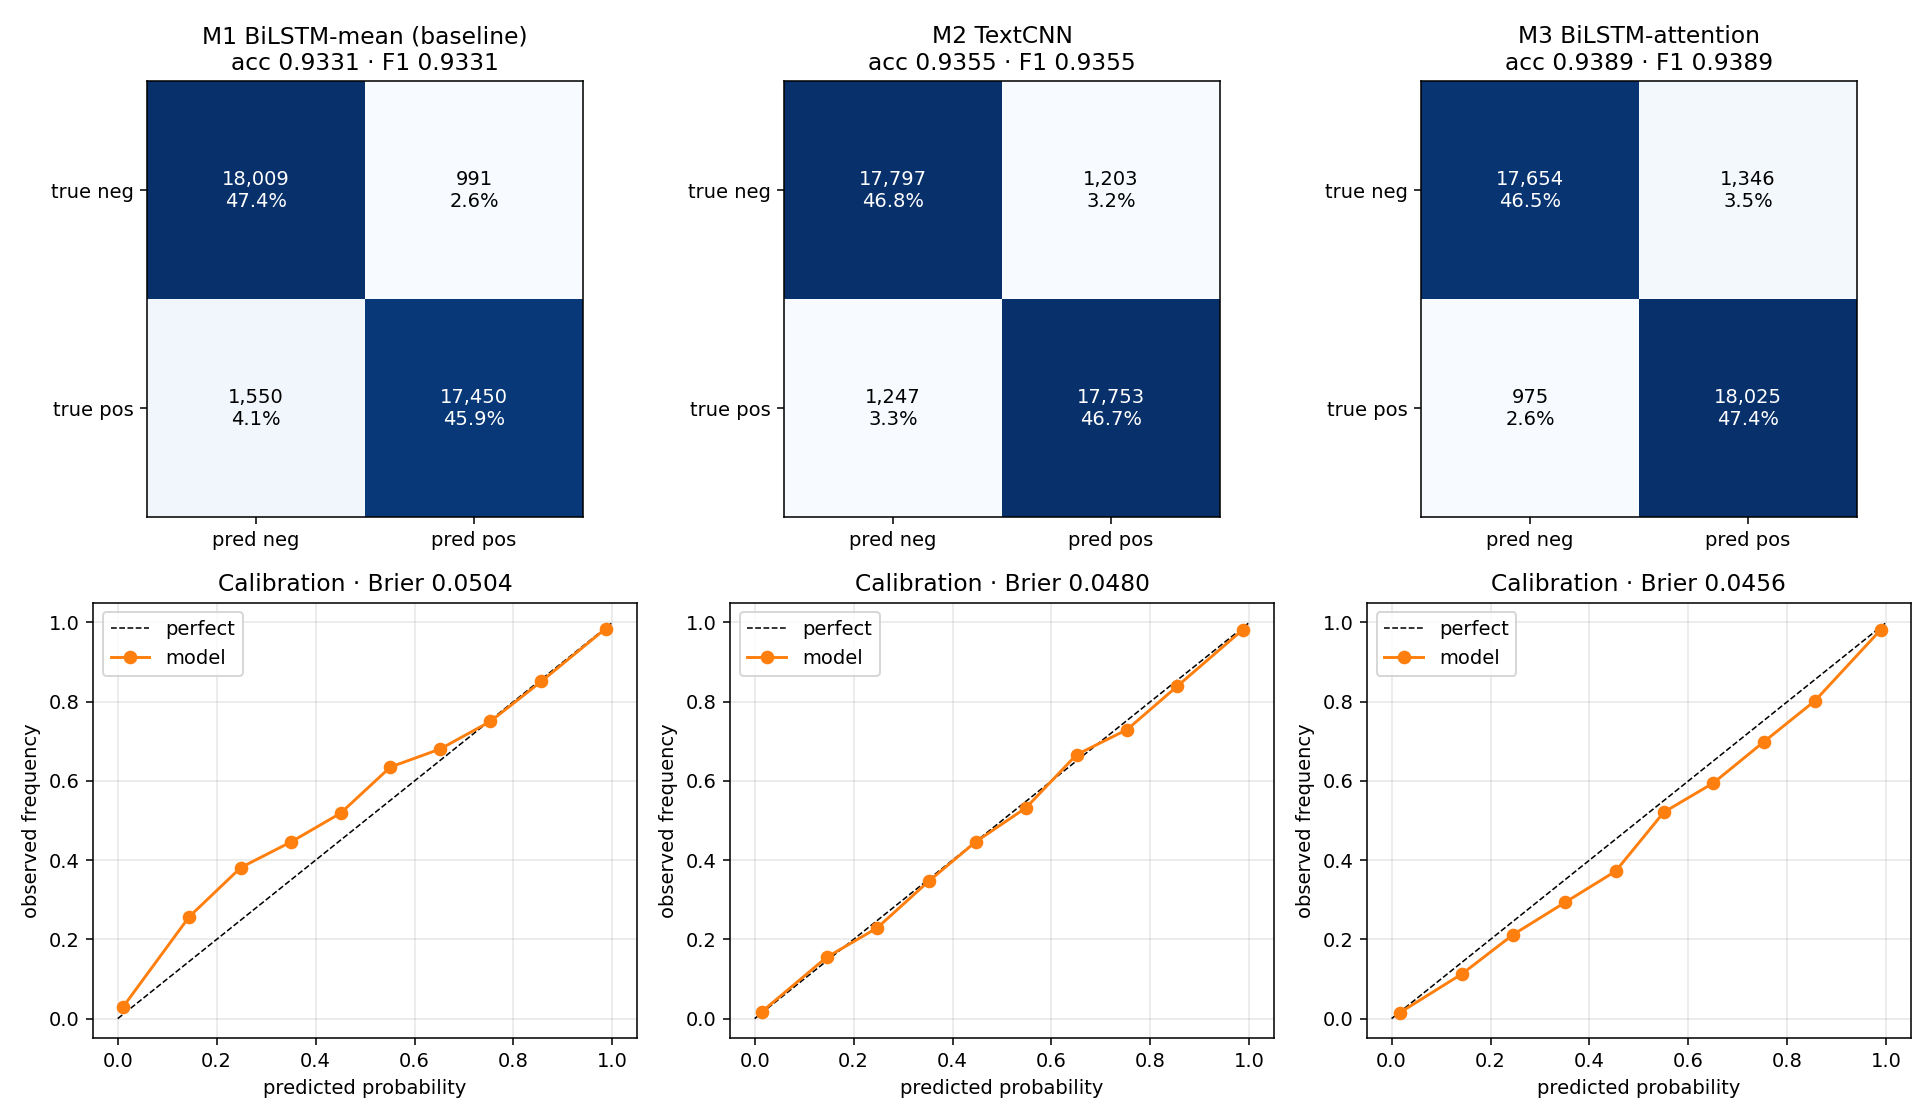

In [10]:
display(Image(filename=str(OUT/'confusion_matrices/confusion_and_calibration.png')))

### 3.2 Per-slice robustness

In [11]:
slice_cols = [c for c in mr.columns if c.startswith('slice_')]
mr.set_index('model_name')[slice_cols].round(5).T

model_name,bilstm_mean,cnn_multikernel,bilstm_attention
slice_short_f1_macro,0.93325,0.93687,0.93984
slice_short_error_rate,0.06580,0.06204,0.05907
slice_long_f1_macro,0.90674,0.90531,0.90924
slice_long_error_rate,0.08073,0.08250,0.08191
slice_negation_f1_macro,0.92722,0.93038,0.93342
slice_negation_error_rate,0.06731,0.06483,0.06257
slice_highpunct_f1_macro,0.95118,0.95315,0.95628
slice_highpunct_error_rate,0.04767,0.04565,0.04234


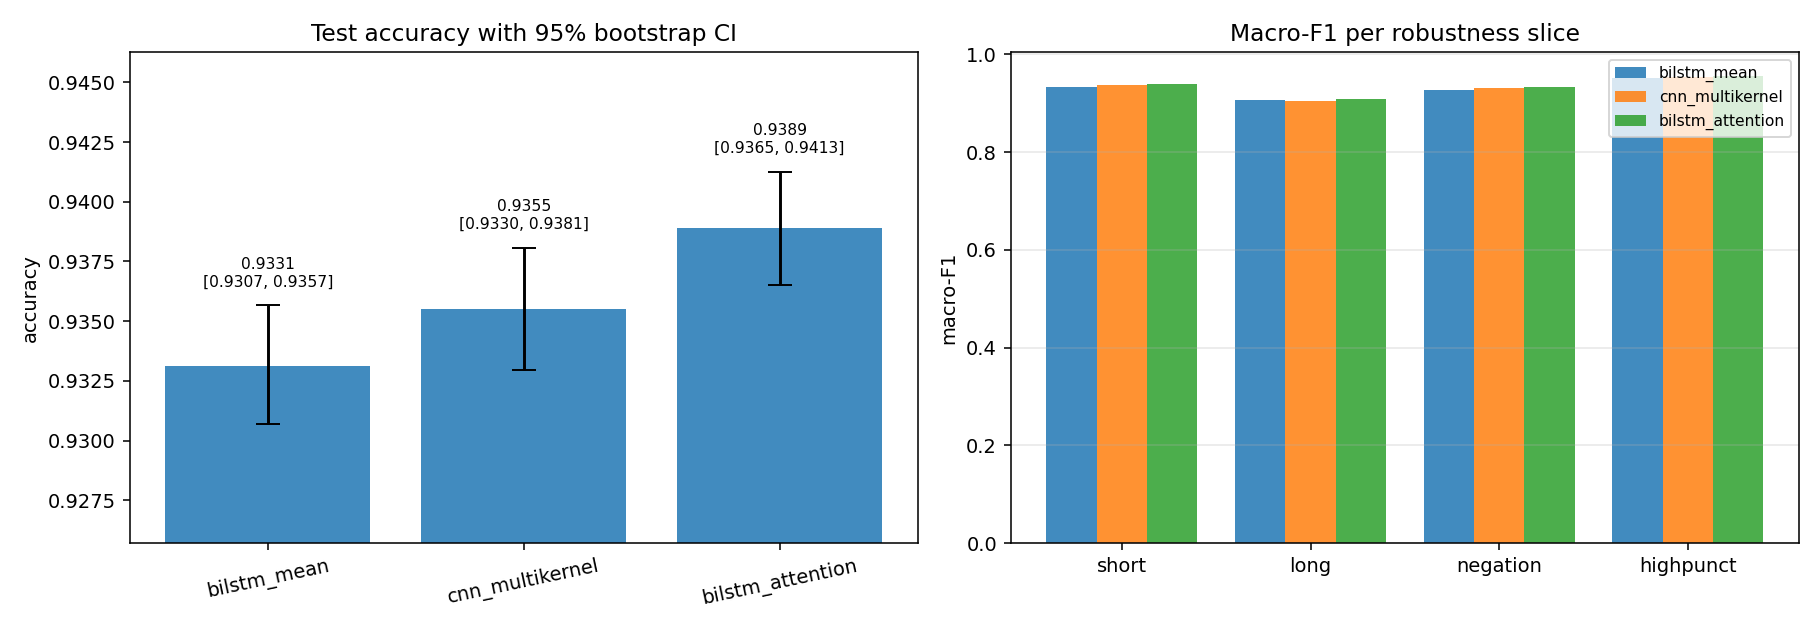

In [12]:
display(Image(filename=str(OUT/'plots/model_comparison.png')))

## 4. Comparative analysis (5 marks)

**Do the confidence intervals overlap?** Overlapping 95% CIs mean the models are not
distinguishable on this test set regardless of the point estimates. The paired McNemar test is
the more sensitive comparison because it conditions on the examples where the two models
disagree.

In [13]:
base = mr[mr.model_name == 'bilstm_mean'].iloc[0]
print(f"{'model':<20}{'acc':>9}{'95% CI':>22}{'overlaps baseline?':>21}")
for _, r in mr.iterrows():
    ov = not (r.acc_ci_low > base.acc_ci_high or r.acc_ci_high < base.acc_ci_low)
    print(f"{r.model_name:<20}{r.accuracy:>9.4f}   [{r.acc_ci_low:.4f}, {r.acc_ci_high:.4f}]"
          f"{('yes' if ov else 'NO - separated'):>21}")

model                     acc                95% CI   overlaps baseline?
bilstm_mean            0.9331   [0.9307, 0.9357]                  yes
cnn_multikernel        0.9355   [0.9330, 0.9381]                  yes
bilstm_attention       0.9389   [0.9365, 0.9413]       NO - separated


In [14]:
from metrics import mcnemar_test
y = np.load(CACHE/'test.npz')['y']
pb = np.load(OUT/'test_probs_t2_m1_baseline.npy')
for tag in ['t2_m2_cnn','t2_m3_bilstm_attn']:
    p = OUT/f'test_probs_{tag}.npy'
    if p.exists():
        r = mcnemar_test(y, pb, np.load(p))
        print(f"{tag}: statistic={r['statistic']:.3f}  p={r['pvalue']:.3e}  "
              f"baseline-only-correct={r['baseline_only_correct']}  "
              f"experimental-only-correct={r['experimental_only_correct']}")

t2_m2_cnn: statistic=3.745  p=5.297e-02  baseline-only-correct=1036  experimental-only-correct=1127
t2_m3_bilstm_attn: statistic=24.470  p=7.548e-07  baseline-only-correct=870  experimental-only-correct=1090


## 5. Manual error review (20 errors)

Five confident false positives, five confident false negatives, five near-threshold errors and
five from the model's worst robustness slice, with the raw review text:
[outputs/error_review_t2_m1_baseline.md](outputs/error_review_t2_m1_baseline.md).

Error types and proposed fixes are assigned by hand in
[failure_analysis.md](failure_analysis.md).

In [15]:
txt = (OUT/'error_review_t2_m1_baseline.md').read_text()
print(txt[:2200])

# Task 2 - Error review: `t2_m1_baseline`

Test accuracy 0.9331 · macro-F1 0.9331 · MCC 0.8666 · Brier 0.0504

Error type vocabulary: `negation` · `sarcasm/irony` · `mixed sentiment` · `aspect confusion` · `rating-text mismatch` · `domain term` · `length truncation` · `rare vocabulary / OOV` · `label noise` · `other`

## A. Confident false positives (predicted positive, actually negative)

### 1. test index 29330 — p(pos) = 1.0000, true = negative
- tokens after preprocessing: 19 · exclamations: 2 · negation present: no

> Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012

- **Error type:** _<assign one>_
- **Testable fix:** _<one change you could make>_
- **Metric that should move:** _<which number, in which direction>_

### 2. test index 3163 — p(pos) = 0.9995, true = negative
- tokens after preprocessing: 7 · exclamations: 0 · negation present: no

> What I love about Rubios' is that they al

Full write-up, architecture justification and limitations: [results.md](results.md).